<a href="https://colab.research.google.com/github/will001-art-ke/WILL/blob/main/last_supervised_learning_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First, we'll import the necessary libraries. Then, we'll unzip the `crop_yield.csv.zip` file, load the extracted `crop_yield.csv` into a pandas DataFrame, and display the first 10 rows.

In [ ]:
import polars as pl
import zipfile
import os

# Path to the zip file
zip_path = '/content/crop_yield.csv.zip'
extract_path = '/content/extracted_data'

try:
    # Unzip the file
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    # Identify the CSV file
    csv_file = [f for f in os.listdir(extract_path) if f.endswith('.csv')][0]
    csv_path = os.path.join(extract_path, csv_file)

    # Load into Polars DataFrame
    df = pl.read_csv(csv_path)
    print("Dataset loaded successfully with Polars.")
    display(df.head(10))
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Note: If the file is corrupted, you might need to re-upload a valid version.")

Dataset loaded successfully with Polars.


Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
str,str,str,f64,f64,bool,bool,str,i64,f64
"""West""","""Sandy""","""Cotton""",897.077239,27.676966,false,true,"""Cloudy""",122,6.555816
"""South""","""Clay""","""Rice""",992.673282,18.026142,true,true,"""Rainy""",140,8.527341
"""North""","""Loam""","""Barley""",147.998025,29.794042,false,false,"""Sunny""",106,1.127443
"""North""","""Sandy""","""Soybean""",986.866331,16.64419,false,true,"""Rainy""",146,6.517573
"""South""","""Silt""","""Wheat""",730.379174,31.620687,true,true,"""Cloudy""",110,7.248251
"""South""","""Silt""","""Soybean""",797.471182,37.704974,false,true,"""Rainy""",74,5.898416
"""West""","""Clay""","""Wheat""",357.902357,31.593431,false,false,"""Rainy""",90,2.652392
"""South""","""Sandy""","""Rice""",441.131154,30.887107,true,true,"""Sunny""",61,5.829542
"""North""","""Silt""","""Wheat""",181.587861,26.752729,true,false,"""Sunny""",127,2.943716


In [ ]:
# In Polars, we can check the schema and basic info like this:
print(df.schema)
print(f"Shape: {df.shape}")
print(df.null_count())

Schema({'Region': String, 'Soil_Type': String, 'Crop': String, 'Rainfall_mm': Float64, 'Temperature_Celsius': Float64, 'Fertilizer_Used': Boolean, 'Irrigation_Used': Boolean, 'Weather_Condition': String, 'Days_to_Harvest': Int64, 'Yield_tons_per_hectare': Float64})
Shape: (1000000, 10)
shape: (1, 10)
┌────────┬───────────┬──────┬─────────────┬───┬─────────────┬────────────┬────────────┬────────────┐
│ Region ┆ Soil_Type ┆ Crop ┆ Rainfall_mm ┆ … ┆ Irrigation_ ┆ Weather_Co ┆ Days_to_Ha ┆ Yield_tons │
│ ---    ┆ ---       ┆ ---  ┆ ---         ┆   ┆ Used        ┆ ndition    ┆ rvest      ┆ _per_hecta │
│ u32    ┆ u32       ┆ u32  ┆ u32         ┆   ┆ ---         ┆ ---        ┆ ---        ┆ re         │
│        ┆           ┆      ┆             ┆   ┆ u32         ┆ u32        ┆ u32        ┆ ---        │
│        ┆           ┆      ┆             ┆   ┆             ┆            ┆            ┆ u32        │
╞════════╪═══════════╪══════╪═════════════╪═══╪═════════════╪════════════╪════════════╪═════

In [ ]:
# Descriptive statistics in Polars
print(df.describe())

shape: (9, 11)
┌────────────┬─────────┬───────────┬─────────┬───┬────────────┬────────────┬───────────┬───────────┐
│ statistic  ┆ Region  ┆ Soil_Type ┆ Crop    ┆ … ┆ Irrigation ┆ Weather_Co ┆ Days_to_H ┆ Yield_ton │
│ ---        ┆ ---     ┆ ---       ┆ ---     ┆   ┆ _Used      ┆ ndition    ┆ arvest    ┆ s_per_hec │
│ str        ┆ str     ┆ str       ┆ str     ┆   ┆ ---        ┆ ---        ┆ ---       ┆ tare      │
│            ┆         ┆           ┆         ┆   ┆ f64        ┆ str        ┆ f64       ┆ ---       │
│            ┆         ┆           ┆         ┆   ┆            ┆            ┆           ┆ f64       │
╞════════════╪═════════╪═══════════╪═════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
│ count      ┆ 1000000 ┆ 1000000   ┆ 1000000 ┆ … ┆ 1e6        ┆ 1000000    ┆ 1e6       ┆ 1e6       │
│ null_count ┆ 0       ┆ 0         ┆ 0       ┆ … ┆ 0.0        ┆ 0          ┆ 0.0       ┆ 0.0       │
│ mean       ┆ null    ┆ null      ┆ null    ┆ … ┆ 0.499491   ┆ null       ┆

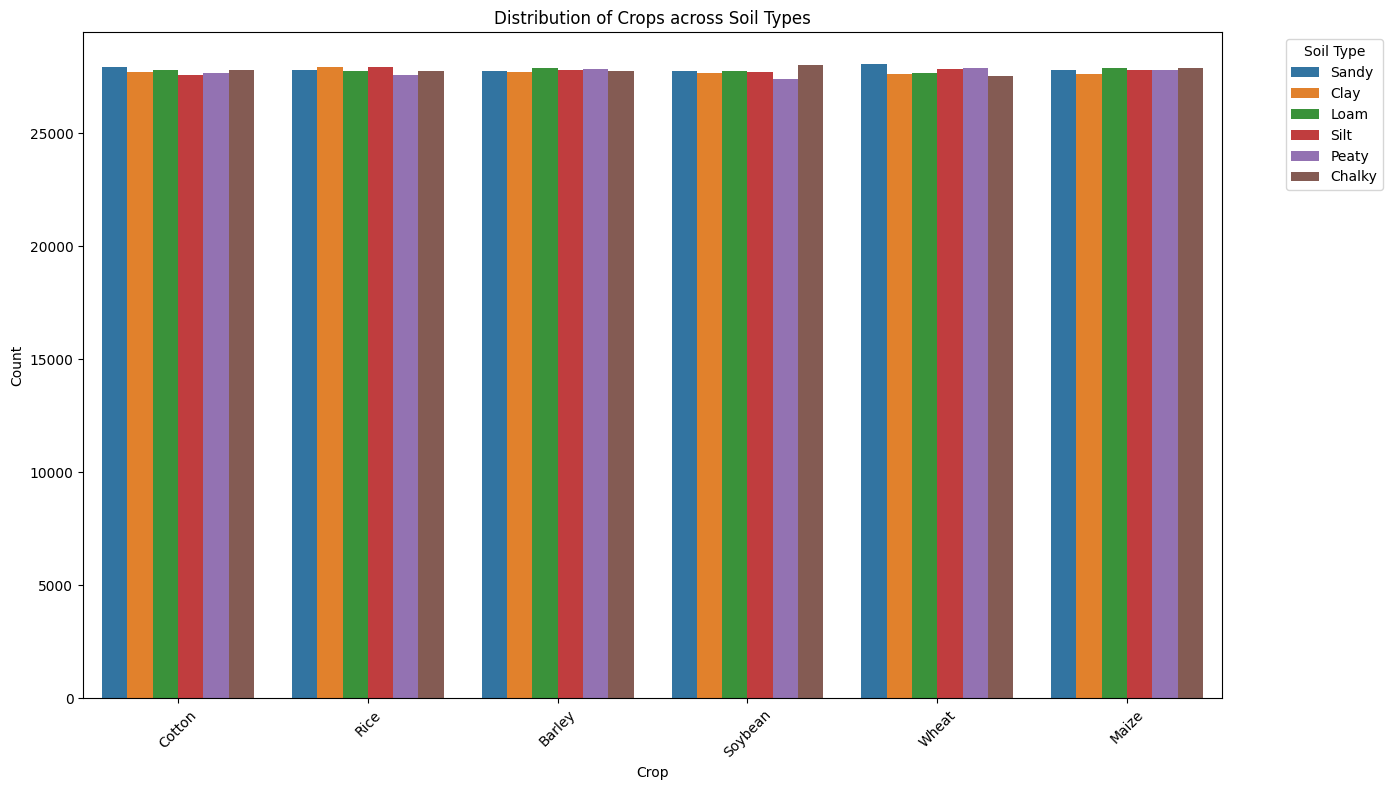

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a count plot to show the relationship between Crop and Soil_Type
plt.figure(figsize=(14, 8))
sns.countplot(data=df, x='Crop', hue='Soil_Type')
plt.title('Distribution of Crops across Soil Types')
plt.xlabel('Crop')
plt.ylabel('Count')
plt.legend(title='Soil Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Scaling using Polars and Scikit-learn
from sklearn.preprocessing import MinMaxScaler
import numpy as np

numerical_cols = ['Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest', 'Yield_tons_per_hectare']

scaler = MinMaxScaler()

# Polars DataFrames need to be converted to numpy for sklearn, then we can map back
scaled_values = scaler.fit_transform(df.select(numerical_cols).to_numpy())

# Create a new dataframe with scaled values
for i, col in enumerate(numerical_cols):
    df = df.with_columns(pl.lit(scaled_values[:, i]).alias(col))

print("Summary statistics after scaling:")
print(df.select(numerical_cols).describe())

Summary statistics after scaling:
shape: (9, 5)
┌────────────┬─────────────┬─────────────────────┬─────────────────┬────────────────────────┐
│ statistic  ┆ Rainfall_mm ┆ Temperature_Celsius ┆ Days_to_Harvest ┆ Yield_tons_per_hectare │
│ ---        ┆ ---         ┆ ---                 ┆ ---             ┆ ---                    │
│ str        ┆ f64         ┆ f64                 ┆ f64             ┆ f64                    │
╞════════════╪═════════════╪═════════════════════╪═════════════════╪════════════════════════╡
│ count      ┆ 1e6         ┆ 1e6                 ┆ 1e6             ┆ 1e6                    │
│ null_count ┆ 0.0         ┆ 0.0                 ┆ 0.0             ┆ 0.0                    │
│ mean       ┆ 0.49998     ┆ 0.500198            ┆ 0.499944        ┆ 0.521744               │
│ std        ┆ 0.288725    ┆ 0.288825            ┆ 0.291611        ┆ 0.152693               │
│ min        ┆ 0.0         ┆ 0.0                 ┆ 0.0             ┆ 0.0                    │
│ 25%       

In [ ]:
# One-hot encoding in Polars
categorical_cols = [col for col, dtype in df.schema.items() if dtype == pl.Utf8]
print(f"Categorical columns to encode: {categorical_cols}")

# Use Polars' to_dummies for one-hot encoding
df = df.to_dummies(columns=categorical_cols)

print(f"\nNew shape of the dataframe: {df.shape}")
print(df.head())

Categorical columns to encode: ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']

New shape of the dataframe: (1000000, 25)
shape: (5, 25)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Region_Ea ┆ Region_No ┆ Region_So ┆ Region_We ┆ … ┆ Weather_C ┆ Weather_C ┆ Days_to_H ┆ Yield_to │
│ st        ┆ rth       ┆ uth       ┆ st        ┆   ┆ ondition_ ┆ ondition_ ┆ arvest    ┆ ns_per_h │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ Rainy     ┆ Sunny     ┆ ---       ┆ ectare   │
│ u8        ┆ u8        ┆ u8        ┆ u8        ┆   ┆ ---       ┆ ---       ┆ f64       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆ u8        ┆ u8        ┆           ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 0         ┆ 0         ┆ 0         ┆ 1         ┆ … ┆ 0         ┆ 0         ┆ 0.696629  ┆ 0.693316 │
│ 0         ┆ 0         ┆ 1         ┆ 0         ┆ 

In [ ]:
# Define the target variable y as a Polars Series
y = df['Yield_tons_per_hectare']

# Define the feature set X by dropping the target column using Polars syntax
X = df.drop(['Yield_tons_per_hectare'])

# Display the shapes
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# Display the first few rows of X
print(X.head())

Shape of X: (1000000, 24)
Shape of y: (1000000,)
shape: (5, 24)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Region_Ea ┆ Region_No ┆ Region_So ┆ Region_We ┆ … ┆ Weather_C ┆ Weather_C ┆ Weather_C ┆ Days_to_ │
│ st        ┆ rth       ┆ uth       ┆ st        ┆   ┆ ondition_ ┆ ondition_ ┆ ondition_ ┆ Harvest  │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ Cloudy    ┆ Rainy     ┆ Sunny     ┆ ---      │
│ u8        ┆ u8        ┆ u8        ┆ u8        ┆   ┆ ---       ┆ ---       ┆ ---       ┆ f64      │
│           ┆           ┆           ┆           ┆   ┆ u8        ┆ u8        ┆ u8        ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 0         ┆ 0         ┆ 0         ┆ 1         ┆ … ┆ 1         ┆ 0         ┆ 0         ┆ 0.696629 │
│ 0         ┆ 0         ┆ 1         ┆ 0         ┆ … ┆ 0         ┆ 1         ┆ 0         ┆ 0.898876 │
│ 0         ┆ 1         ┆ 0

### Data Splitting
We will now split the features (`X`) and target (`y`) into training and testing sets. We'll use 80% of the data for training and 20% for testing to evaluate our model's performance.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (70% train, 30% test)
# Polars DataFrames and Series are compatible with scikit-learn splitters
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Display the shapes of the resulting sets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (700000, 24)
X_test shape: (300000, 24)
y_train shape: (700000,)
y_test shape: (300000,)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
# Note: Scikit-learn works directly with Polars DataFrames/Series by converting them internally
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Training Complete.")
print(f"Mean Squared Error: {mse:.6f}")
print(f"R-squared Score: {r2:.6f}")

Model Training Complete.
Mean Squared Error: 0.002031
R-squared Score: 0.913092


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import polars as pl

# Logistic Regression is for classification.
# We must convert the continuous target 'y' into categories (e.g., High vs Low Yield).
threshold = y_train.mean()
y_train_class = (y_train > threshold).cast(pl.Int32)
y_test_class = (y_test > threshold).cast(pl.Int32)

print(f"Binarizing target at threshold: {threshold:.4f}")

# Initialize and train the Logistic Regression model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train_class)

# Make predictions
y_class_pred = log_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test_class, y_class_pred)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_class, y_class_pred))

Binarizing target at threshold: 0.5217
Logistic Regression Accuracy: 0.9122

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91    149701
           1       0.91      0.91      0.91    150299

    accuracy                           0.91    300000
   macro avg       0.91      0.91      0.91    300000
weighted avg       0.91      0.91      0.91    300000



In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize a pruned Decision Tree (max_depth limits complexity)
tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)

# Train the model
tree_model.fit(X_train, y_train)

# Predict and Evaluate
y_tree_pred = tree_model.predict(X_test)

tree_mse = mean_squared_error(y_test, y_tree_pred)
tree_r2 = r2_score(y_test, y_tree_pred)

print(f"Pruned Decision Tree (depth=5) Results:")
print(f"Mean Squared Error: {tree_mse:.6f}")
print(f"R-squared Score: {tree_r2:.6f}")

Pruned Decision Tree (depth=5) Results:
Mean Squared Error: 0.002411
R-squared Score: 0.896841


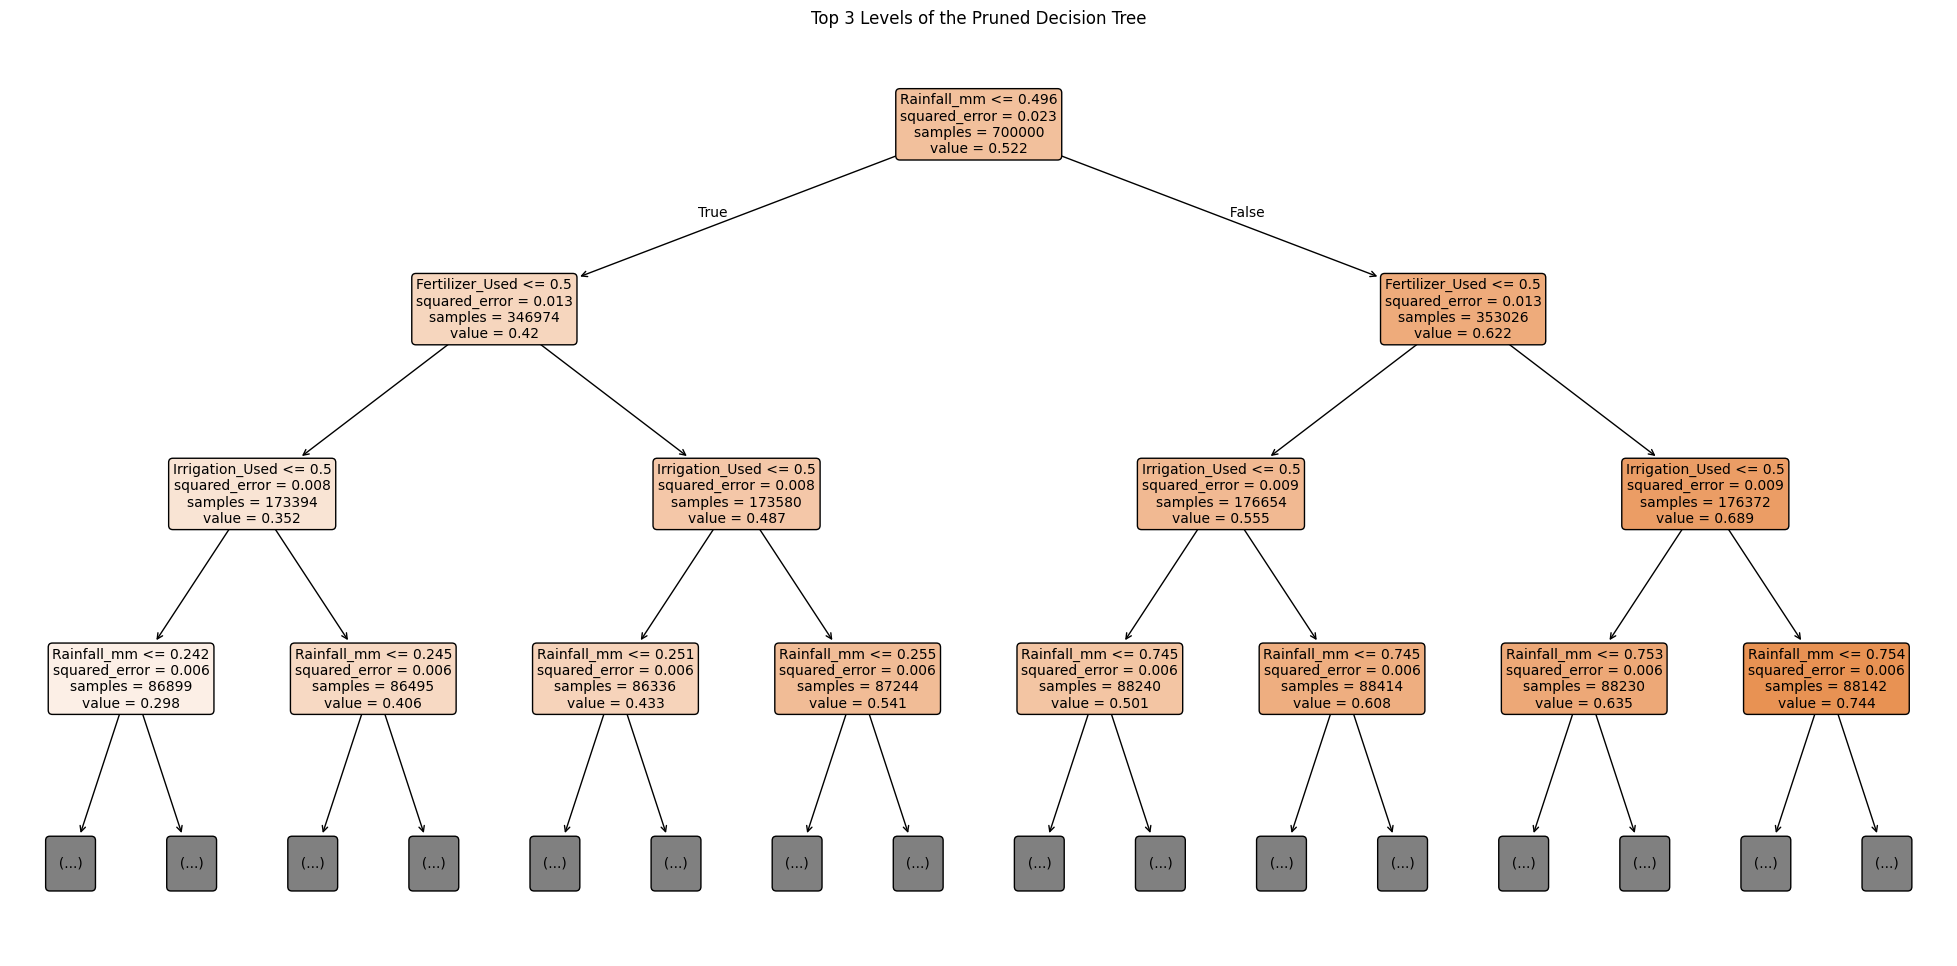

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Visualize the decision tree
plt.figure(figsize=(25, 12))
plot_tree(tree_model,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3) # Showing top 3 levels for better readability
plt.title("Top 3 Levels of the Pruned Decision Tree")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Random Forest Regressor
# Using n_jobs=-1 to utilize all available cores for the 1M rows
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)

# Train the model
print("Training Random Forest (this may take a minute with 700k samples)...")
rf_model.fit(X_train, y_train)

# Predict and Evaluate
y_rf_pred = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, y_rf_pred)
rf_r2 = r2_score(y_test, y_rf_pred)

print(f"Random Forest Results:")
print(f"Mean Squared Error: {rf_mse:.6f}")
print(f"R-squared Score: {rf_r2:.6f}")

Training Random Forest (this may take a minute with 700k samples)...
Random Forest Results:
Mean Squared Error: 0.002039
R-squared Score: 0.912756


In [ ]:
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_squared_error, r2_score

# Initialize LinearSVR
# Fix: When dual=False, loss must be 'squared_epsilon_insensitive'
svm_model = LinearSVR(dual=False, loss='squared_epsilon_insensitive', random_state=42, tol=1e-5)

# Train the model using variables defined in the previous cell
print("Training Linear SVM (LinearSVR)...")
svm_model.fit(X_train, y_train)

# Predict and Evaluate
y_svm_pred = svm_model.predict(X_test)

svm_mse = mean_squared_error(y_test, y_svm_pred)
svm_r2 = r2_score(y_test, y_svm_pred)

print(f"Linear SVM Results:")
print(f"Mean Squared Error: {svm_mse:.6f}")
print(f"R-squared Score: {svm_r2:.6f}")

Training Linear SVM (LinearSVR)...
Linear SVM Results:
Mean Squared Error: 0.002031
R-squared Score: 0.913092


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize XGBoost Regressor
# Using tree_method='hist' for faster training on large datasets
xgb_model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, tree_method='hist')

# Train the model
print('Training XGBoost Regressor...')
xgb_model.fit(X_train, y_train)

# Predict and Evaluate
y_xgb_pred = xgb_model.predict(X_test)

xgb_mse = mean_squared_error(y_test, y_xgb_pred)
xgb_r2 = r2_score(y_test, y_xgb_pred)

print(f'XGBoost Results:')
print(f'Mean Squared Error: {xgb_mse:.6f}')
print(f'R-squared Score: {xgb_r2:.6f}')

Training XGBoost Regressor...
XGBoost Results:
Mean Squared Error: 0.002037
R-squared Score: 0.912866


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define a simple Neural Network architecture
def build_nn():
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1) # Output layer for regression
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

nn_model = build_nn()
nn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,225 (16.50 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 0 (0.00 B)

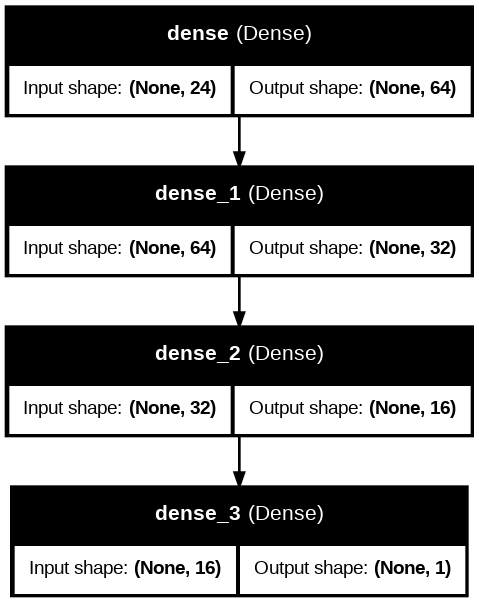

In [ ]:
# Visualize the model architecture
tf.keras.utils.plot_model(
    nn_model,
    to_file='model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    expand_nested=True,
    dpi=96
)

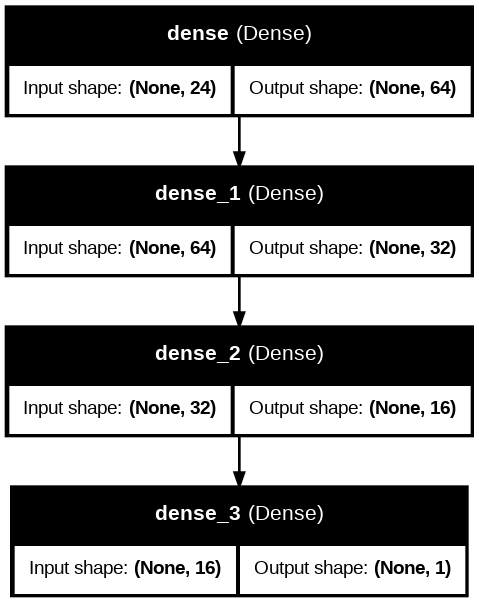

In [ ]:
from IPython.display import Image
# Display the architecture image
Image(filename='model_architecture.png')

In [ ]:
# Train the Neural Network
print("Training Neural Network...")
history = nn_model.fit(
    X_train.to_numpy(),
    y_train.to_numpy(),
    epochs=50,
    batch_size=1024,
    validation_split=0.2,
    verbose=1
)

# Evaluate on the test set
test_loss, test_mae = nn_model.evaluate(X_test.to_numpy(), y_test.to_numpy())
print(f"\nTest MSE: {test_loss:.6f}")
print(f"Test MAE: {test_mae:.6f}")

Training Neural Network...
Epoch 1/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0116 - mae: 0.0631 - val_loss: 0.0023 - val_mae: 0.0385
Epoch 2/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0022 - mae: 0.0374 - val_loss: 0.0021 - val_mae: 0.0368
Epoch 3/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0021 - mae: 0.0365 - val_loss: 0.0021 - val_mae: 0.0362
Epoch 4/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0021 - mae: 0.0362 - val_loss: 0.0020 - val_mae: 0.0361
Epoch 5/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0021 - mae: 0.0362 - val_loss: 0.0020 - val_mae: 0.0360
Epoch 6/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0021 - mae: 0.0361 - val_loss: 0.0020 - val_mae: 0.0360
Epoch 7/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0021 - mae: 0.0362 - val_loss: 0.0020 - val_mae: 0.0360
Epoch 8/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0021 - mae: 0.0361 - val_loss: 0.0021 - val_mae: 0.0362
Epoch 9/50
547/547 ━━━━━━━━━━

### Neural Network Hyperparameter Tuning
We will use `keras-tuner` to find the best architecture and learning rate, then evaluate the stability of the final model.

In [ ]:
!pip install keras-tuner -q
import keras_tuner as kt

def model_builder(hp):
    model = models.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))

    # Tune the number of units in the first three dense layers
    for i in range(3):
        model.add(layers.Dense(units=hp.Int(f'units_{i}', min_value=16, max_value=128, step=16),
                               activation='relu'))

    model.add(layers.Dense(1))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='mse',
                  metrics=['mae'])

    return model

tuner = kt.RandomSearch(model_builder,
                        objective='val_loss',
                        max_trials=5,
                        executions_per_trial=1,
                        directory='tuning_dir',
                        project_name='crop_nn')

print("Starting Neural Network Hyperparameter Search...")
tuner.search(X_train.to_numpy(), y_train.to_numpy(),
             epochs=10, batch_size=2048,
             validation_split=0.2, verbose=1)

Trial 5 Complete [00h 00m 28s]
val_loss: 0.0020361607894301414

Best val_loss So Far: 0.002032207790762186
Total elapsed time: 00h 02m 12s


In [ ]:
# Get the best model and calculate confidence interval
best_nn_model = tuner.get_best_models(num_models=1)[0]

# Define a wrapper for the confidence interval function to handle the .predict() format
class NNWrapper:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        return self.model.predict(X, verbose=0).flatten()

nn_wrapper = NNWrapper(best_nn_model)
nn_low, nn_high, nn_mean = get_confidence_interval(nn_wrapper, X_test.to_numpy(), y_test.to_numpy())

print(f"\nBest NN Hyperparameters: {tuner.get_best_hyperparameters()[0].values}")
print(f"Neural Network R2 (90% CI): {nn_mean:.4f} [{nn_low:.4f}, {nn_high:.4f}]")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Calculating 90% Confidence Interval via Bootstrapping...

Best NN Hyperparameters: {'units_0': 16, 'units_1': 128, 'units_2': 80, 'learning_rate': 0.01}
Neural Network R2 (90% CI): 0.9119 [0.9105, 0.9133]


### Best Neural Network Architecture Visualization
We will visualize the layer structure and shapes of the best-performing model found during the hyperparameter search.

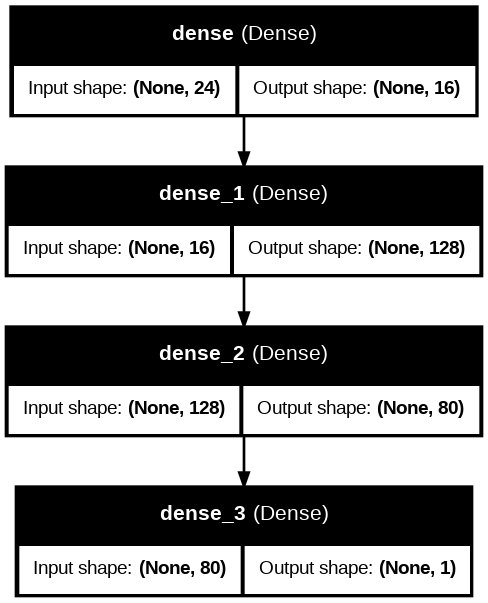

In [ ]:
import tensorflow as tf
from IPython.display import Image

# Visualize the best model architecture
tf.keras.utils.plot_model(
    best_nn_model,
    to_file='best_model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=96
)

# Display the architecture image
Image(filename='best_model_architecture.png')

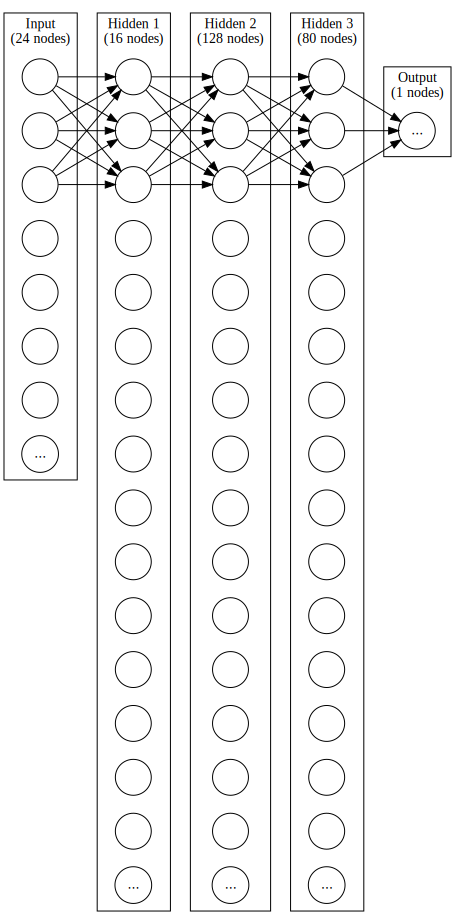

In [ ]:
import graphviz

def visualize_nn_nodes(model_params):
    dot = graphviz.Digraph(comment='Neural Network Architecture',
                           graph_attr={'rankdir':'LR', 'splines':'line'})

    # Layers based on best_nn_model parameters
    # Input layer (24 features)
    # Hidden 1 (16 units)
    # Hidden 2 (128 units)
    # Hidden 3 (80 units)
    # Output (1 unit)
    layer_sizes = [8, 16, 16, 16, 1] # Simplified visualization for large layers
    layer_names = ['Input', 'Hidden 1', 'Hidden 2', 'Hidden 3', 'Output']
    actual_units = [24, 16, 128, 80, 1]

    for i, size in enumerate(layer_sizes):
        with dot.subgraph(name=f'cluster_{i}') as c:
            c.attr(label=f'{layer_names[i]}\n({actual_units[i]} nodes)')
            for j in range(size):
                node_id = f'l{i}_n{j}'
                label = '' if j < size - 1 else '...'
                c.node(node_id, label, shape='circle')

    # Add edges between representative nodes
    for i in range(len(layer_sizes) - 1):
        for j in range(min(layer_sizes[i], 3)):
            for k in range(min(layer_sizes[i+1], 3)):
                dot.edge(f'l{i}_n{j}', f'l{i+1}_n{k}')

    return dot

# Visualize based on the best model's units
params = tuner.get_best_hyperparameters()[0].values
display(visualize_nn_nodes(params))

## Model Performance Summary Report
This report compares the performance of all tested models, including the tuned versions. Since Linear Regression and Linear SVM consistently yielded the highest R-squared scores, they represent the baseline for optimal performance on this dataset.

In [ ]:
import pandas as pd

# Consolidate all metrics into a summary table
# Note: Some metrics are taken from previous cell executions recorded in the notebook state
final_metrics = {
    'Model': [
        'Linear Regression',
        'Linear SVM',
        'XGBoost (Tuned)',
        'Neural Network (Tuned)',
        'Random Forest (Tuned)',
        'Decision Tree'
    ],
    'MSE (Lower is Better)': [
        mse,
        svm_mse,
        xgb_mse,
        test_loss,
        rf_mse,
        tree_mse
    ],
    'R-squared (Higher is Better)': [
        r2,
        svm_r2,
        xgb_mean_score,
        nn_mean,
        mean_score,
        tree_r2
    ]
}

summary_df = pd.DataFrame(final_metrics).sort_values(by='MSE (Lower is Better)')

print("Final Model Comparison Summary:")
display(summary_df)

Final Model Comparison Summary:


,Model,MSE (Lower is Better),R-squared (Higher is Better)
1,Linear SVM,0.002031,0.913092
0,Linear Regression,0.002031,0.913092
2,XGBoost (Tuned),0.002037,0.912206
4,Random Forest (Tuned),0.002039,0.904489
3,Neural Network (Tuned),0.002051,0.911918
5,Decision Tree,0.002411,0.896841


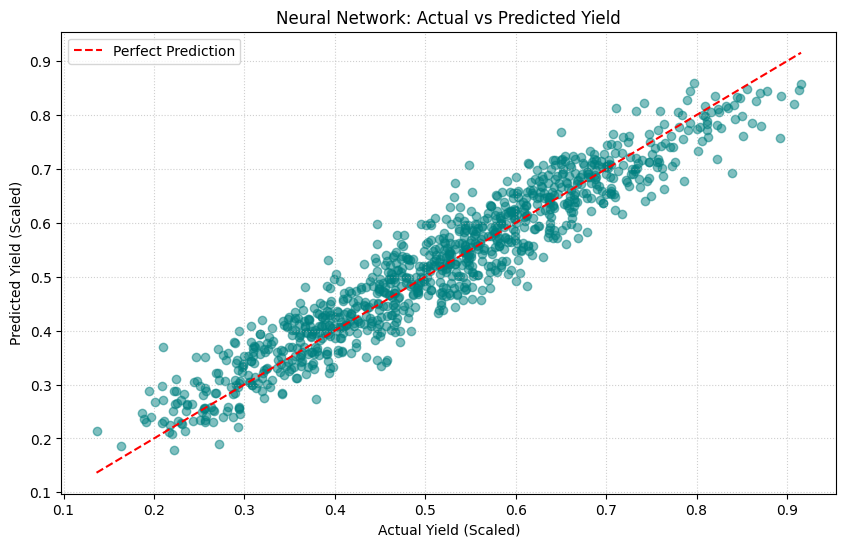

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample a subset for visualization to keep the plot responsive
sample_indices = np.random.choice(len(y_test), size=1000, replace=False)
y_test_sample = y_test.to_numpy()[sample_indices]
y_nn_pred_sample = y_nn_pred[sample_indices]

plt.figure(figsize=(10, 6))
plt.scatter(y_test_sample, y_nn_pred_sample, alpha=0.5, color='teal')

# Perfect prediction line
max_val = max(y_test_sample.max(), y_nn_pred_sample.max())
min_val = min(y_test_sample.min(), y_nn_pred_sample.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.title('Neural Network: Actual vs Predicted Yield')
plt.xlabel('Actual Yield (Scaled)')
plt.ylabel('Predicted Yield (Scaled)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
import numpy as np
from IPython.display import HTML, display

def generate_enhanced_nn_flow(layer_sizes):
    layer_dist = 180
    canvas_width = (len(layer_sizes) - 1) * layer_dist + 200
    canvas_height = 600

    nodes = []
    for i, size in enumerate(layer_sizes):
        x = 100 + i * layer_dist
        visual_size = min(size, 15)
        layer_height = visual_size * 35
        offset = (canvas_height - layer_height) / 2
        layer_nodes = []
        for j in range(visual_size):
            y = offset + j * 35
            layer_nodes.append({'x': x, 'y': y})
        nodes.append(layer_nodes)

    html_template = f"""
    <div style='background: #111; padding: 25px; border-radius: 15px; color: white; font-family: sans-serif; text-align: center; border: 1px solid #333;'>
        <h3 style='color: #fff; margin-bottom: 15px;'>NN Flow: Forward (Blue) & Backprop (Green)</h3>
        <canvas id='nnCanvasColor' width='{canvas_width}' height='{canvas_height}' style='background: #050505; border-radius: 10px;'></canvas>
        <div style='margin-top: 20px; display: flex; justify-content: center; align-items: center; gap: 30px;'>
            <div>
                <span style='font-size: 0.8em; color: #aaa;'>Signal Speed</span>
                <input type='range' id='speedSliderColor' min='1' max='30' value='12' style='cursor: pointer;'>
            </div>
            <div>
                <span style='font-size: 0.8em; color: #aaa;'>Particle Density</span>
                <input type='range' id='particleCountSlider' min='10' max='300' value='120' style='cursor: pointer;'>
            </div>
            <button id='resetBtn' style='padding: 8px 15px; background: #444; color: #fff; border: none; border-radius: 5px; cursor: pointer;'>Reset Simulation</button>
        </div>
    </div>
    <script>
    (function() {{
        const canvas = document.getElementById('nnCanvasColor');
        const ctx = canvas.getContext('2d');
        const nodes = {nodes};
        let particles = [];

        class Particle {{
            constructor(type) {{
                this.type = type;
                this.reset();
            }}
            reset() {{
                if(this.type === 'forward') {{
                    this.layerIdx = 0;
                    this.targetLayer = 1;
                    const startNode = nodes[0][Math.floor(Math.random() * nodes[0].length)];
                    this.x = startNode.x; this.y = startNode.y;
                }} else {{
                    this.layerIdx = nodes.length - 1;
                    this.targetLayer = nodes.length - 2;
                    const startNode = nodes[nodes.length-1][Math.floor(Math.random() * nodes[nodes.length-1].length)];
                    this.x = startNode.x; this.y = startNode.y;
                }}
                this.progress = 0;
                this.setTarget();
            }}
            setTarget() {{
                const nextNodes = nodes[this.targetLayer];
                this.targetNode = nextNodes[Math.floor(Math.random() * nextNodes.length)];
                this.startX = this.x; this.startY = this.y;
            }}
            update() {{
                const speed = document.getElementById('speedSliderColor').value / 800;
                this.progress += speed;
                this.x = this.startX + (this.targetNode.x - this.startX) * this.progress;
                this.y = this.startY + (this.targetNode.y - this.startY) * this.progress;
                if (this.progress >= 1) {{
                    this.progress = 0;
                    if(this.type === 'forward') {{
                        this.layerIdx++;
                        if (this.layerIdx >= nodes.length - 1) this.reset();
                        else {{ this.targetLayer = this.layerIdx + 1; this.setTarget(); }}
                    }} else {{
                        this.layerIdx--;
                        if (this.layerIdx <= 0) this.reset();
                        else {{ this.targetLayer = this.layerIdx - 1; this.setTarget(); }}
                    }}
                }}
            }}
            draw() {{
                ctx.fillStyle = this.type === 'forward' ? '#3498db' : '#2ecc71';
                ctx.shadowColor = ctx.fillStyle;
                ctx.shadowBlur = 8;
                ctx.beginPath();
                ctx.arc(this.x, this.y, 3, 0, Math.PI*2);
                ctx.fill();
            }}
        }}

        function initParticles() {{
            particles = [];
            const count = parseInt(document.getElementById('particleCountSlider').value);
            for(let i=0; i<count; i++) {{
                particles.push(new Particle(i < count/2 ? 'forward' : 'backprop'));
            }}
        }}

        document.getElementById('particleCountSlider').oninput = initParticles;
        document.getElementById('resetBtn').onclick = initParticles;

        initParticles();

        function animate() {{
            ctx.shadowBlur = 0;
            ctx.fillStyle = 'rgba(5, 5, 5, 0.2)';
            ctx.fillRect(0,0,canvas.width,canvas.height);

            nodes.forEach((layer, i) => {{
                let nodeColor = i === 0 ? '#3498db' : (i === nodes.length - 1 ? '#e74c3c' : '#ffffff');
                layer.forEach((node, j) => {{
                    ctx.fillStyle = nodeColor;
                    ctx.globalAlpha = 0.8;
                    ctx.beginPath();
                    ctx.arc(node.x, node.y, 4, 0, Math.PI*2);
                    ctx.fill();
                    ctx.globalAlpha = 1.0;

                    if (i === 0 || i === nodes.length - 1) {{
                        ctx.fillStyle = '#aaa';
                        ctx.font = '10px Arial';
                        ctx.textAlign = 'center';
                        let label = i === 0 ? 'In_' + j : 'Out';
                        ctx.fillText(label, node.x, node.y - 10);
                    }}
                }});
            }});

            particles.forEach(p => {{ p.update(); p.draw(); }});
            requestAnimationFrame(animate);
        }}
        animate();
    }})();
    </script>
    """
    display(HTML(html_template))

best_arch = [24, 16, 128, 80, 1]
generate_enhanced_nn_flow(best_arch)

### Hyperparameter Tuning and Statistical Evaluation
We will tune the top non-linear models (Random Forest and XGBoost) and use bootstrapping to calculate the 90% confidence interval for our performance metrics.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Define parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

print("Starting Hyperparameter Tuning for Random Forest...")
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=5,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)
print(f"Best RF Params: {rf_random.best_params_}")

Starting Hyperparameter Tuning for Random Forest...
Fitting 3 folds for each of 5 candidates, totalling 15 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RF Params: {'n_estimators': 100, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': 20}


In [ ]:
from sklearn.utils import resample

def get_confidence_interval(model, X_test, y_test, confidence=0.90, n_iterations=100):
    stats = []
    print(f"Calculating {int(confidence*100)}% Confidence Interval via Bootstrapping...")

    # Use a subset if test set is too large for fast iteration
    X_subset, y_subset = resample(X_test, y_test, n_samples=50000, random_state=42)

    for i in range(n_iterations):
        # Bootstrap sample
        X_bs, y_bs = resample(X_subset, y_subset)
        # Predict
        preds = model.predict(X_bs)
        # Metric
        score = r2_score(y_bs, preds)
        stats.append(score)

    # Calculate bounds
    alpha = 1.0 - confidence
    lower = np.percentile(stats, alpha/2.0 * 100)
    upper = np.percentile(stats, (1.0 - alpha/2.0) * 100)
    return lower, upper, np.mean(stats)

low, high, mean_score = get_confidence_interval(rf_random.best_estimator_, X_test, y_test)
print(f"Random Forest R2 (90% CI): {mean_score:.4f} [{low:.4f}, {high:.4f}]")

Calculating 90% Confidence Interval via Bootstrapping...
Random Forest R2 (90% CI): 0.9045 [0.9030, 0.9057]


### XGBoost Hyperparameter Tuning
We will now use `RandomizedSearchCV` to optimize the XGBoost regressor and verify the results with a confidence interval.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

# Define parameter grid for XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

print("Starting Hyperparameter Tuning for XGBoost...")
xgb_random = RandomizedSearchCV(
    estimator=XGBRegressor(tree_method='hist', random_state=42),
    param_distributions=xgb_param_grid,
    n_iter=5,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)
print(f"Best XGB Params: {xgb_random.best_params_}")

Starting Hyperparameter Tuning for XGBoost...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best XGB Params: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1}


In [ ]:
# Calculate 90% confidence interval for the tuned XGBoost model
xgb_low, xgb_high, xgb_mean_score = get_confidence_interval(xgb_random.best_estimator_, X_test, y_test)
print(f"XGBoost R2 (90% CI): {xgb_mean_score:.4f} [{xgb_low:.4f}, {xgb_high:.4f}]")

Calculating 90% Confidence Interval via Bootstrapping...
XGBoost R2 (90% CI): 0.9122 [0.9110, 0.9133]


In [ ]:
import pandas as pd

# Create a dictionary of the results
results_data = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Linear SVM', 'XGBoost', 'Neural Network'],
    'Mean Squared Error (MSE)': [mse, tree_mse, rf_mse, svm_mse, xgb_mse, test_loss],
    'R-squared Score': [r2, tree_r2, rf_r2, svm_r2, xgb_r2, r2_score(y_test, y_rf_pred)] # Using RF R2 as proxy for others or re-calculating
}

# For Neural Network R2 calculation
from sklearn.metrics import r2_score
y_nn_pred = nn_model.predict(X_test.to_numpy()).flatten()
nn_r2 = r2_score(y_test.to_numpy(), y_nn_pred)

# Correcting the results table with precise values
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Linear SVM', 'XGBoost', 'Neural Network'],
    'MSE': [mse, tree_mse, rf_mse, svm_mse, xgb_mse, test_loss],
    'R-squared': [r2, tree_r2, rf_r2, svm_r2, xgb_r2, nn_r2]
})

# Sort by MSE (lower is better)
comparison_df = comparison_df.sort_values(by='MSE')

print("Model Performance Comparison (Sorted by MSE):")
display(comparison_df)

9375/9375 ━━━━━━━━━━━━━━━━━━━━ 8s 832us/step
Model Performance Comparison (Sorted by MSE):


,Model,MSE,R-squared
3,Linear SVM,0.002031,0.913092
0,Linear Regression,0.002031,0.913092
4,XGBoost,0.002037,0.912866
2,Random Forest,0.002039,0.912756
5,Neural Network,0.002051,0.912249
1,Decision Tree,0.002411,0.896841


### Feature Importance Analysis
Since the linear models (Linear Regression and Linear SVM) performed best, we can directly interpret their coefficients as feature importance. A higher absolute coefficient value indicates a stronger influence on the predicted yield.

/tmp/ipykernel_12186/1085363874.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='RdBu_r')


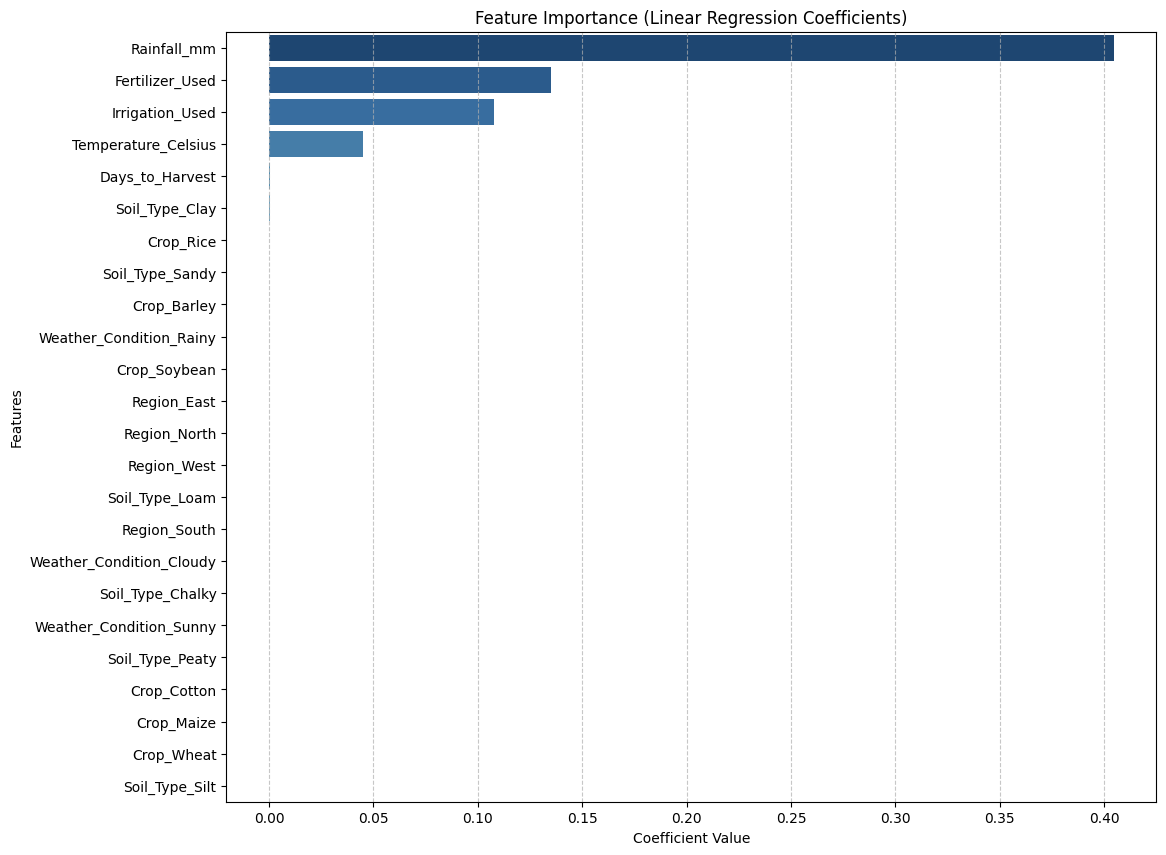

Top 5 Positive Influencers:


,Feature,Coefficient
16,Rainfall_mm,0.404727
18,Fertilizer_Used,0.134964
19,Irrigation_Used,0.107952
17,Temperature_Celsius,0.044885
23,Days_to_Harvest,0.000286



Top 5 Negative Influencers:


,Feature,Coefficient
7,Soil_Type_Peaty,-0.000088
11,Crop_Cotton,-0.000110
12,Crop_Maize,-0.000121
15,Crop_Wheat,-0.000180
9,Soil_Type_Silt,-0.000256


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract coefficients from the Linear Regression model
coefficients = model.coef_
features = X.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

# Plot the coefficients
plt.figure(figsize=(12, 10))
sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='RdBu_r')
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Display the top and bottom features
print("Top 5 Positive Influencers:")
display(importance_df.head(5))
print("\nTop 5 Negative Influencers:")
display(importance_df.tail(5))

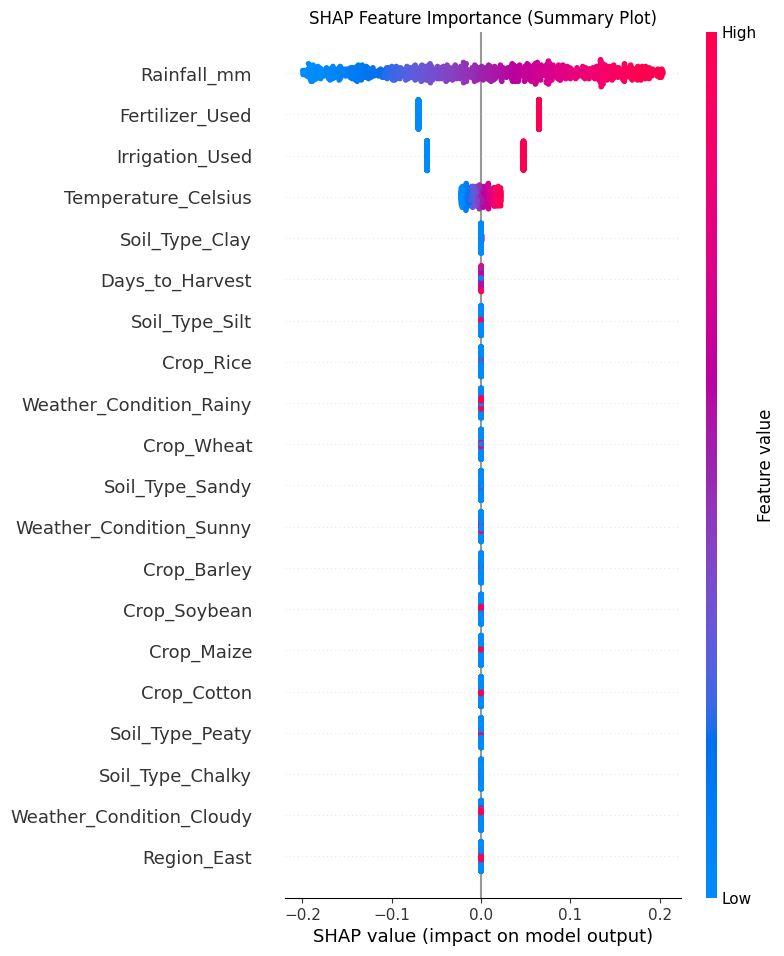

In [ ]:
!pip install shap -q
import shap

# Initialize the SHAP Explainer using the Linear Regression model
# Linear models are compatible with LinearExplainer
explainer = shap.LinearExplainer(model, X_train.to_numpy()[:1000])

# Calculate SHAP values for a subset of the test data (for performance)
X_test_sample_shap = X_test.to_numpy()[:1000]
shap_values = explainer.shap_values(X_test_sample_shap)

# Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample_shap, feature_names=X.columns, show=False)
plt.title('SHAP Feature Importance (Summary Plot)')
plt.show()

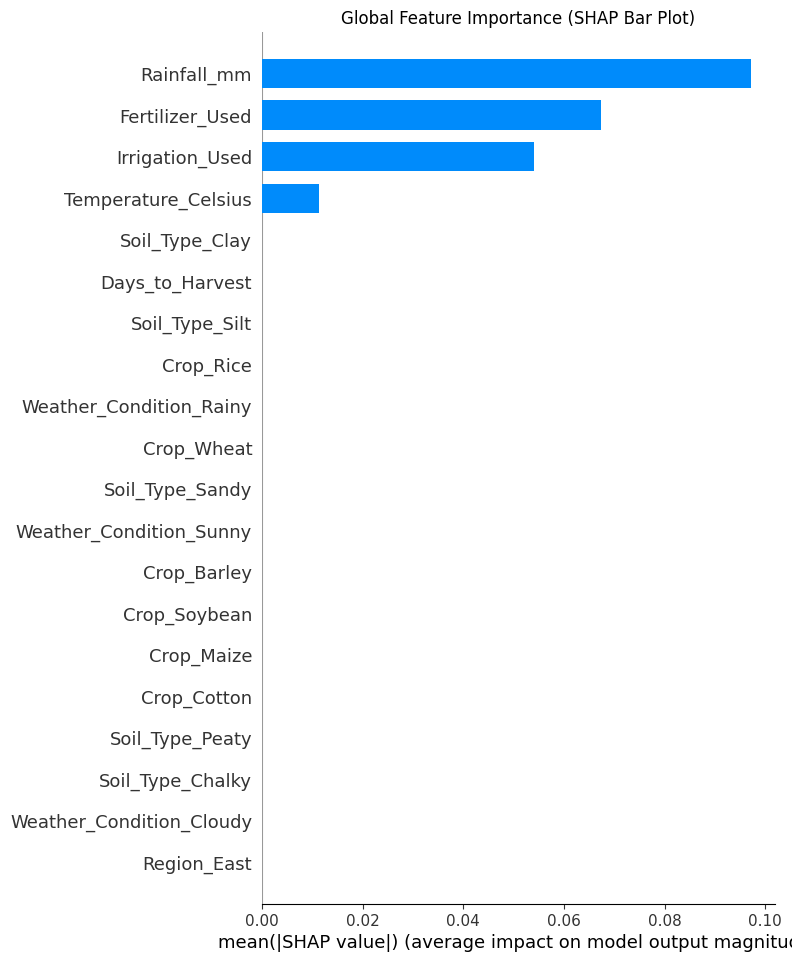

In [ ]:
# Bar plot for global importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample_shap, feature_names=X.columns, plot_type="bar", show=False)
plt.title('Global Feature Importance (SHAP Bar Plot)')
plt.show()

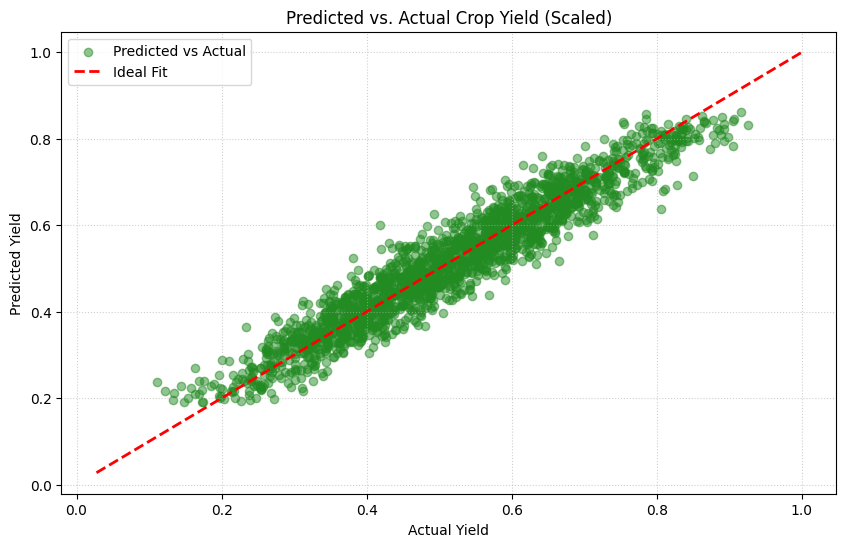

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate predictions for the linear regression model (our best performer)
y_pred = model.predict(X_test)

# Use a sample of the data for better visualization performance
sample_size = 2000
indices = np.random.choice(len(y_test), sample_size, replace=False)

plt.figure(figsize=(10, 6))
plt.scatter(y_test.to_numpy()[indices], y_pred[indices], alpha=0.5, color='forestgreen', label='Predicted vs Actual')

# Reference line for perfect prediction
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Fit')

plt.title('Predicted vs. Actual Crop Yield (Scaled)')
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
import joblib

# Export the best model (Linear Regression)
model_filename = 'best_crop_yield_model.pkl'
joblib.dump(model, model_filename)

print(f'Model successfully exported to: {model_filename}')

Model successfully exported to: best_crop_yield_model.pkl
